# 03. Modelling

Three classifiers on the kidney cohort, targeting `readmission_under_30_days`:

| Model | Notes |
|---|---|
| Logistic Regression | interpretable baseline |
| Random Forest | non-linear, chosen model in the original project |
| XGBoost + SMOTE | gradient boosting with minority oversampling |

Each is wrapped in a pipeline (`ColumnTransformer` -> `SimpleImputer` -> classifier) so that
scaling and encoding are fit on the training fold only.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report,
    precision_recall_curve, precision_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROCESSED = Path("../data/processed")
MODELS = Path("../models")
FIG = Path("../figures")
MODELS.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

RANDOM_STATE = 42

## Configuration

Two switches control how faithful the run is to the original project.

- `INCLUDE_READMIT_FEATURE`: the original feature set contained `readmit`, the count of prior
  visits carrying the same ICD code. It is highly correlated with the target by construction.
  Set to `False` to see what the models look like without it.
- `GROUP_SPLIT_BY_PATIENT`: the original used a plain random split. Because the table has one row
  per (admission x diagnosis code), the same patient can land in both train and test. Set to
  `True` to split on `subject_id` instead, so no patient appears on both sides.

Defaults reproduce the original. Read `LIMITATIONS.md` before quoting any number from this
notebook.


In [2]:
INCLUDE_READMIT_FEATURE = False   # original: True
GROUP_SPLIT_BY_PATIENT = True   # original: False
TEST_SIZE = 0.2
DECISION_THRESHOLD = 0.30        # original dashboard threshold

## 1. Load the cohort and assemble the design matrix

In [3]:
cohort = pd.read_parquet(PROCESSED / "kidney_cohort.parquet")

TARGET = "readmission_under_30_days"

numeric_features = [
    "anchor_age", "los_hours", "severity",
    "previous_admissions_count", "hospital_expire_flag",
]
if INCLUDE_READMIT_FEATURE:
    numeric_features.append("readmit")

categorical_features = ["gender", "icd_code", "admission_location", "insurance"]

features = numeric_features + categorical_features
X = cohort[features]
y = cohort[TARGET]
groups = cohort["subject_id"]

print(f"rows: {len(X):,}   features: {len(features)}")
print(f"class balance: {y.value_counts(normalize=True).round(3).to_dict()}")

rows: 261,347   features: 9
class balance: {0: 0.742, 1: 0.258}


## 2. Train / test split

In [4]:
if GROUP_SPLIT_BY_PATIENT:
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    print(f"patients in both splits: {len(overlap)}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

print(f"train: {len(X_train):,}   test: {len(X_test):,}")

patients in both splits: 0
train: 209,273   test: 52,074


## 3. Preprocessing

`ColumnTransformer` standardises the numeric columns and one-hot encodes the categorical ones.
`icd_code` is high cardinality, so unseen codes at test time are ignored rather than raising.


In [5]:
def make_preprocessor(impute_strategy: str = "median") -> ColumnTransformer:
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy=impute_strategy)),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

## 4. Evaluation helper

In [6]:
def evaluate(name, model, X_test, y_test, threshold=DECISION_THRESHOLD):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f"===== {name} =====")
    print(f"threshold          : {threshold}")
    print(f"precision (class 1): {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"ROC AUC            : {roc_auc_score(y_test, proba):.4f}")
    print(f"PR AUC             : {average_precision_score(y_test, proba):.4f}")
    print()
    print(classification_report(y_test, pred, digits=2))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[0], colorbar=False)
    axes[0].set_title(f"{name}: confusion matrix")

    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].set_title(f"{name}: ROC")
    axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[2].plot(rec, prec, label=f"AP = {average_precision_score(y_test, proba):.3f}")
    axes[2].axhline(y_test.mean(), color="k", ls="--", lw=0.8, label="baseline")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"{name}: precision-recall")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(FIG / f"{name.lower().replace(' ', '_')}_metrics.png", dpi=150,
                bbox_inches="tight")
    plt.show()

    return {
        "model": name,
        "precision": precision_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "predicted_positive_rate": pred.mean(),
    }


results = []

## 5. Logistic Regression

===== Logistic Regression =====
threshold          : 0.3
precision (class 1): 0.4289
ROC AUC            : 0.6745
PR AUC             : 0.3936

              precision    recall  f1-score   support

           0       0.80      0.84      0.82     39378
           1       0.43      0.36      0.39     12696

    accuracy                           0.73     52074
   macro avg       0.62      0.60      0.61     52074
weighted avg       0.71      0.73      0.72     52074



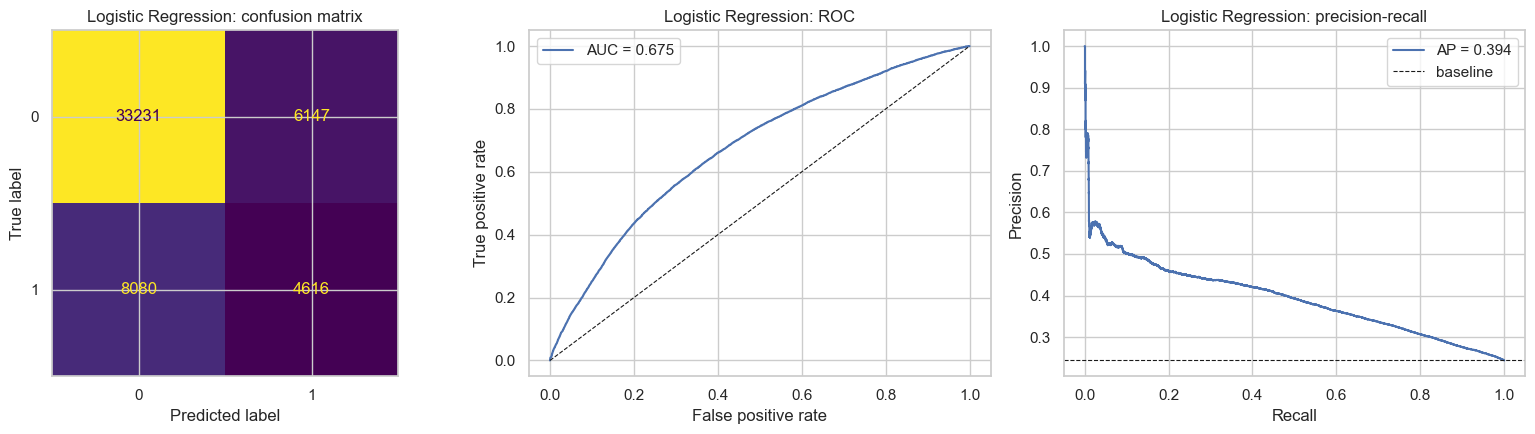

In [7]:
logreg = Pipeline([
    ("prep", make_preprocessor(impute_strategy="mean")),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
results.append(evaluate("Logistic Regression", logreg, X_test, y_test))

## 6. Random Forest

===== Random Forest =====
threshold          : 0.3
precision (class 1): 0.3764
ROC AUC            : 0.7390
PR AUC             : 0.4349

              precision    recall  f1-score   support

           0       0.87      0.62      0.73     39378
           1       0.38      0.70      0.49     12696

    accuracy                           0.64     52074
   macro avg       0.62      0.66      0.61     52074
weighted avg       0.75      0.64      0.67     52074



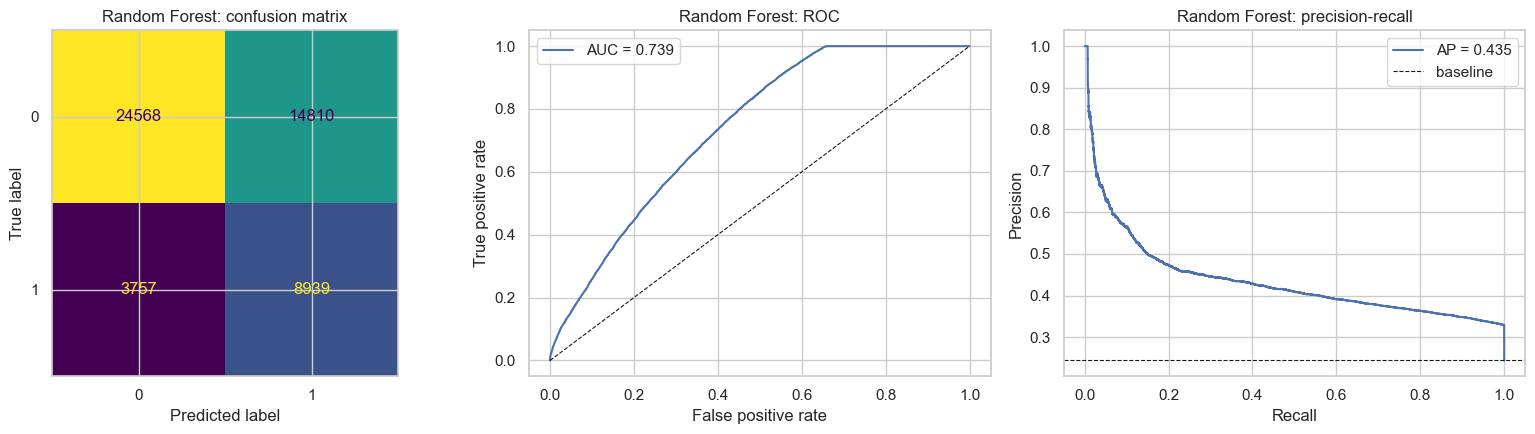

In [8]:
rf = Pipeline([
    ("prep", make_preprocessor(impute_strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

## 7. XGBoost with SMOTE

SMOTE sits *inside* the pipeline, so synthetic minority samples are generated from the training
fold only and never leak into the held-out set.


===== XGBoost SMOTE =====
threshold          : 0.3
precision (class 1): 0.3344
ROC AUC            : 0.7359
PR AUC             : 0.4270

              precision    recall  f1-score   support

           0       0.97      0.38      0.55     39378
           1       0.33      0.97      0.50     12696

    accuracy                           0.52     52074
   macro avg       0.65      0.67      0.52     52074
weighted avg       0.82      0.52      0.53     52074



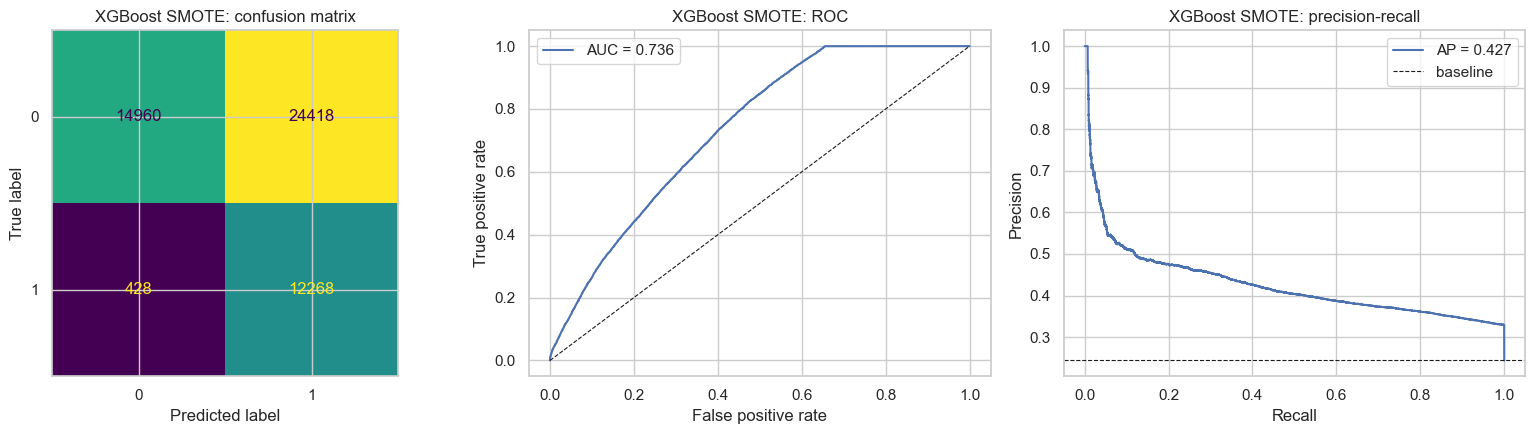

In [9]:
xgb = ImbPipeline([
    ("prep", make_preprocessor(impute_strategy="median")),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost SMOTE", xgb, X_test, y_test))

## 8. Model comparison

In [10]:
summary = pd.DataFrame(results).set_index("model").round(4)
summary

,precision,roc_auc,pr_auc,predicted_positive_rate
model,,,,
Logistic Regression,0.4289,0.6745,0.3936,0.2067
Random Forest,0.3764,0.7390,0.4349,0.4561
XGBoost SMOTE,0.3344,0.7359,0.4270,0.7045


Accuracy is deliberately absent. With a minority class this size, a model that predicts
"no readmission" for everyone already scores well on accuracy while being useless. PR AUC and
recall at the operating threshold are the numbers that matter.


## 9. Predicted readmission profile

The original project reported the share of kidney patients flagged as at-risk, then broke that
share down by age band and severity. Reproduced here for the Random Forest.


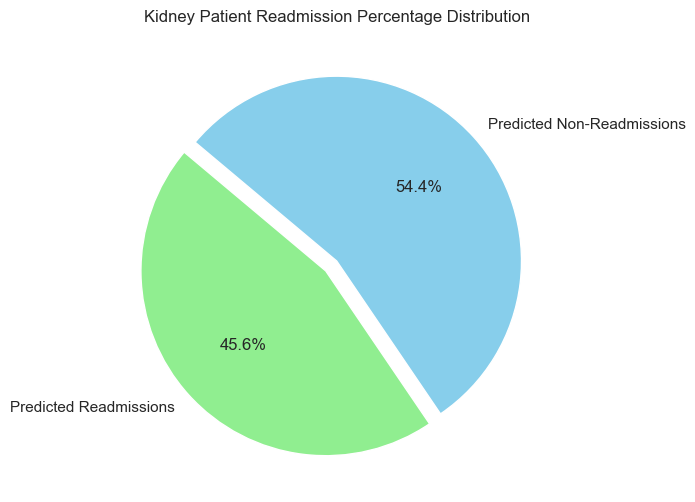

In [11]:
best = rf
proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= DECISION_THRESHOLD).astype(int)

flagged = pred.mean()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [flagged, 1 - flagged],
    labels=["Predicted Readmissions", "Predicted Non-Readmissions"],
    autopct="%1.1f%%",
    colors=["#90ee90", "#87ceeb"],
    explode=[0.08, 0],
    startangle=140,
)
ax.set_title("Kidney Patient Readmission Percentage Distribution")
plt.savefig(FIG / "predicted_readmission_share.png", dpi=150, bbox_inches="tight")
plt.show()

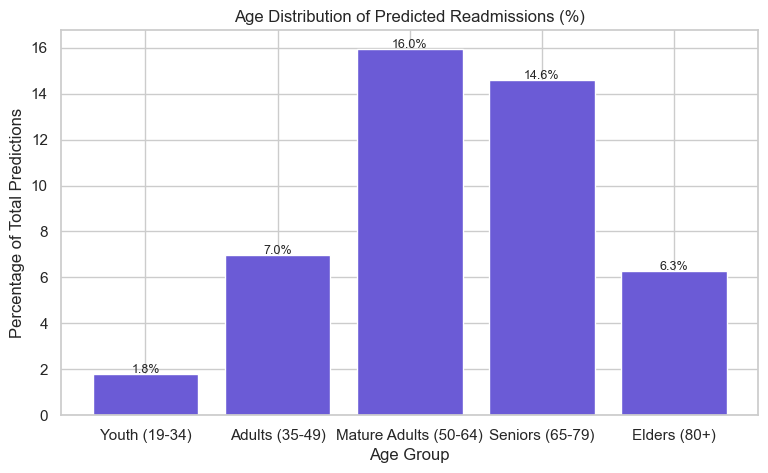

In [12]:
test_view = X_test.copy()
test_view["predicted"] = pred

bins = [18, 34, 49, 64, 79, 120]
labels = ["Youth (19-34)", "Adults (35-49)", "Mature Adults (50-64)",
          "Seniors (65-79)", "Elders (80+)"]
test_view["age_group"] = pd.cut(test_view["anchor_age"], bins=bins, labels=labels)

age_pct = (
    test_view[test_view["predicted"] == 1]["age_group"].value_counts().sort_index()
    / len(test_view) * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(age_pct.index.astype(str), age_pct.values, color="#6b5bd6")
for i, v in enumerate(age_pct.values):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage of Total Predictions")
ax.set_title("Age Distribution of Predicted Readmissions (%)")
plt.savefig(FIG / "predicted_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

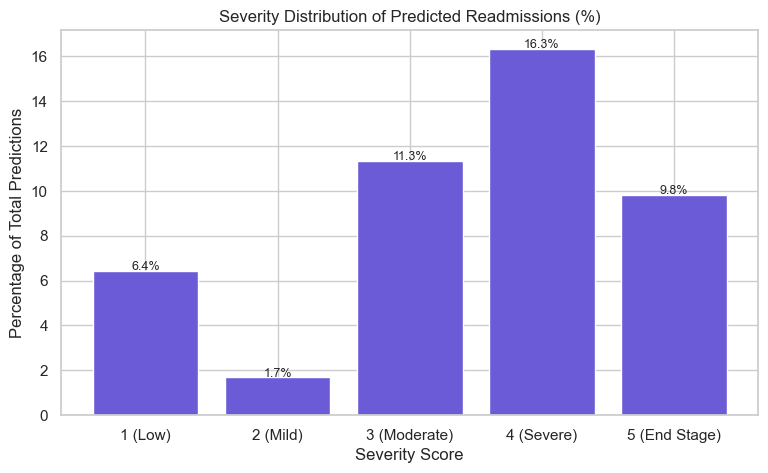

In [13]:
sev_labels = {1: "1 (Low)", 2: "2 (Mild)", 3: "3 (Moderate)",
              4: "4 (Severe)", 5: "5 (End Stage)"}

sev_pct = (
    test_view[test_view["predicted"] == 1]["severity"].value_counts().sort_index()
    / len(test_view) * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([sev_labels.get(s, s) for s in sev_pct.index], sev_pct.values, color="#6b5bd6")
for i, v in enumerate(sev_pct.values):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Severity Score")
ax.set_ylabel("Percentage of Total Predictions")
ax.set_title("Severity Distribution of Predicted Readmissions (%)")
plt.savefig(FIG / "predicted_by_severity.png", dpi=150, bbox_inches="tight")
plt.show()

The original report read the low share of severe cases as evidence that severe patients get
better care and therefore return less. A competing explanation is survivorship: the sickest
patients are the ones who die in hospital or transition to hospice, and a patient who does not
survive cannot be readmitted. `hospital_expire_flag` is in the feature set, so the model can see
part of this. Treat the severity gradient as descriptive, not causal.


## 10. Feature importance

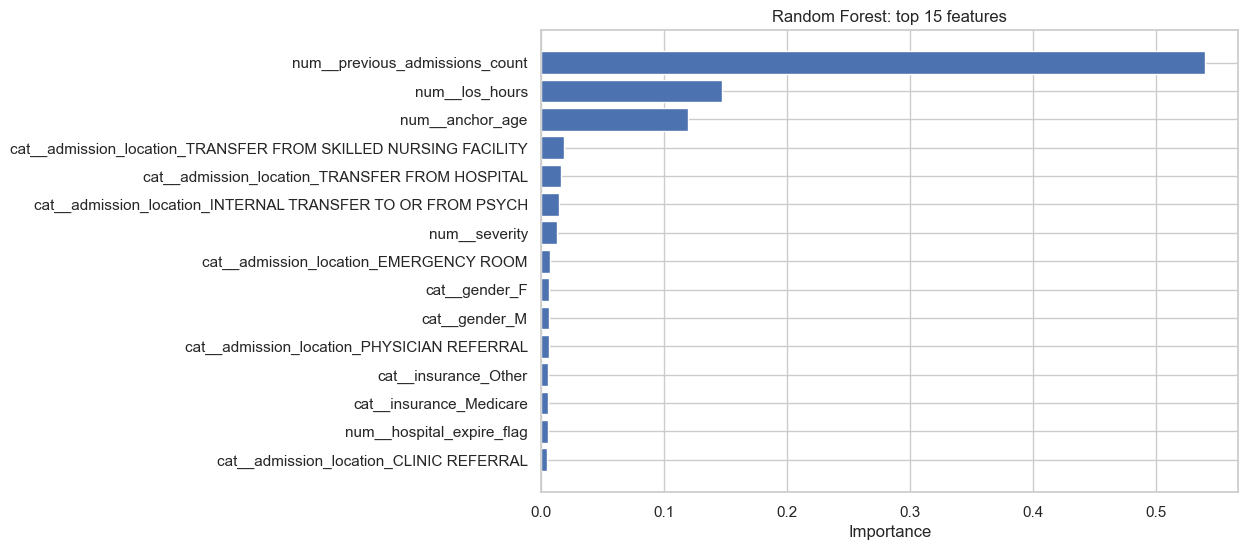

In [14]:
encoder = rf.named_steps["prep"]
feature_names = encoder.get_feature_names_out()
importances = rf.named_steps["clf"].feature_importances_

imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color="#4c72b0")
ax.set_xlabel("Importance")
ax.set_title("Random Forest: top 15 features")
plt.savefig(FIG / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Persist the chosen model for the dashboard

In [15]:
artifact = {
    "model": rf,
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "threshold": DECISION_THRESHOLD,
    "include_readmit_feature": INCLUDE_READMIT_FEATURE,
    "group_split_by_patient": GROUP_SPLIT_BY_PATIENT,
}

joblib.dump(artifact, MODELS / "readmission_rf.joblib")
print("saved models/readmission_rf.joblib")

saved models/readmission_rf.joblib
